In [1]:
import concurrent.futures
import os
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pathlib import Path
from huggingface_hub import HfApi, hf_hub_download
from huggingface_hub.hf_api import RepoFile, RepoFolder
from tqdm.notebook import tqdm

# To load HF_TOKEN from .env file if it exists
load_dotenv()

True

In [2]:
REPO_ID = "neilrigaud/hagrid-subset"
REPO_TYPE = "dataset"

BASE_DIR = Path.cwd().parent
OUTPUT_DIR = os.path.normpath(os.path.join(BASE_DIR, "data", "raw"))
LIMIT_PER_CLASS = 2500
MAX_WORKERS = 2
TARGET_SPLIT = "train"

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project root: {BASE_DIR}")
print(f"Data will be saved to: {OUTPUT_DIR}")

Project root: D:\Coding\PyCharm\gesture-recognizer
Data will be saved to: D:\Coding\PyCharm\gesture-recognizer\data\raw


In [3]:
def download_file(args):
    file_path, local_dir = args
    try:
        hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=file_path, local_dir=local_dir,
                        token=os.getenv("HF_TOKEN"))

        return True
    except Exception as e:
        tqdm.write(f"Failed to download {file_path}: {e}")
        return False

In [4]:
api = HfApi()
stats = {}

print(f"Initializing dataset download: {REPO_ID} (Split: {TARGET_SPLIT})")

try:
    tree = api.list_repo_tree(repo_id=REPO_ID, repo_type=REPO_TYPE, path_in_repo=TARGET_SPLIT, recursive=False)
    classes = [item for item in tree if isinstance(item, RepoFolder)]
except Exception as e:
    raise RuntimeError(f"Error retrieving repository structure: {e}")

total_downloaded = 0

for class_folder in classes:
    class_name = class_folder.path.split("/")[-1]
    print(f"Processing class: {class_name}")

    try:
        files = api.list_repo_tree(
            repo_id=REPO_ID, repo_type=REPO_TYPE, path_in_repo=class_folder.path, recursive=False
        )
    except Exception as e:
        tqdm.write(f"Error accessing class {class_name}: {e}")
        continue

    image_files = [
        f.path for f in files
        if isinstance(f, RepoFile) and f.path.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    files_to_download = image_files[:LIMIT_PER_CLASS]
    if not files_to_download:
        stats[class_name] = 0
        continue

    tasks = [(f, OUTPUT_DIR) for f in files_to_download]

    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        results = list(tqdm(
            executor.map(download_file, tasks),
            total=len(tasks),
            desc=class_name,
            leave=True
        ))

    downloaded_in_class = sum(results)
    stats[class_name] = downloaded_in_class
    total_downloaded += downloaded_in_class

print(f"Download completed. Total files saved: {total_downloaded}")

Initializing dataset download: neilrigaud/hagrid-subset (Split: train)
Processing class: call


call:   0%|          | 0/2500 [00:00<?, ?it/s]

Processing class: dislike


dislike:   0%|          | 0/2500 [00:00<?, ?it/s]

Processing class: fist


...

Processing class: two_up


two_up:   0%|          | 0/2500 [00:00<?, ?it/s]

Processing class: two_up_inverted


two_up_inverted:   0%|          | 0/2500 [00:00<?, ?it/s]

Download completed. Total files saved: 56464


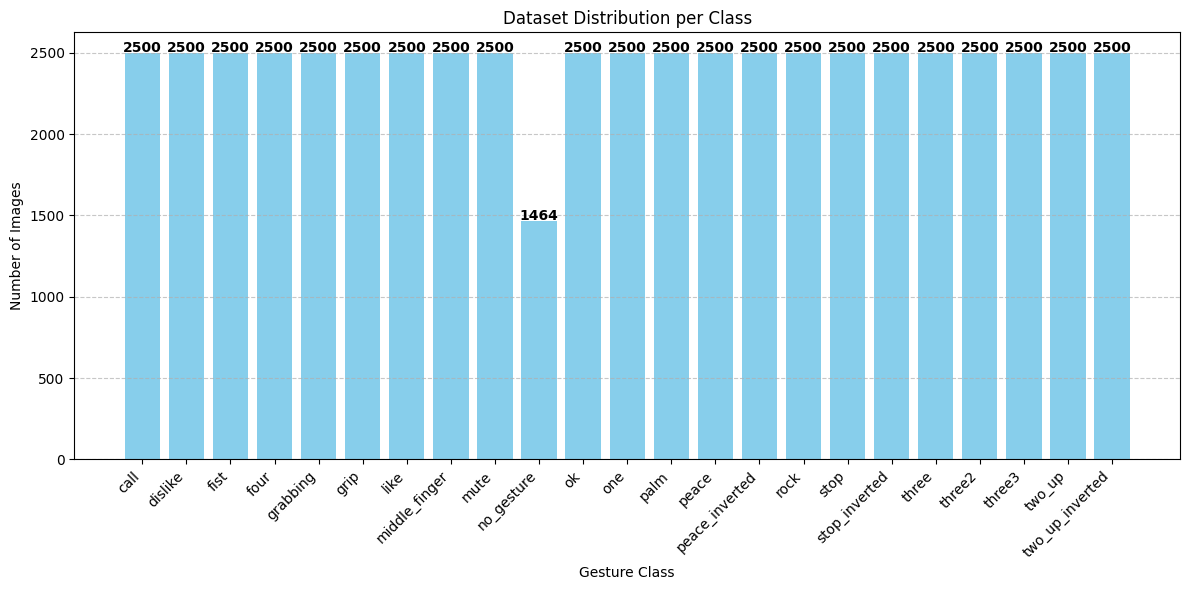

In [5]:
if stats:
    plt.figure(figsize=(12, 6))

    names = list(stats.keys())
    values = list(stats.values())

    plt.bar(names, values, color='skyblue')
    plt.xlabel('Gesture Class')
    plt.ylabel('Number of Images')
    plt.title('Dataset Distribution per Class')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(values):
        plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()